In [2]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 65.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 6.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=9ddd2da58d063befe15204db87986bc10d7331e5720416123ab225fa70027d95
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


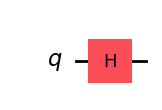

In [3]:

# Create a circuit with one qubit
circuit = QuantumCircuit(1)

# Add a Hadamard (H) gate on qubit 0, to create a superposition
circuit.h(0)

# Draw the circuit diagram. Delete "mpl" to get a text diagram.
circuit.draw("mpl")

In [4]:
# Now simulate the circuit by calculating the effect on state vectors.
# Set the initial state of the simulator to |0>
# The state vector has two coefficients, both 0
state = Statevector.from_int(0, 2) #this initialises the qubit to the |0> state

# Apply the circuit to the state
state = state.evolve(circuit)

# Display using latex. This requires the pylatexenc module.
# Omit "latex" to get a numerical (not algebraic) view of the state vector.
state.draw("latex")

<IPython.core.display.Latex object>

In [5]:
# A different way of dislaying the state, again using latex
from qiskit.visualization import array_to_latex

array_to_latex(state)

<IPython.core.display.Latex object>

In [6]:
# The whole circuit is a unitary operator, which we can display.

U = Operator(circuit)
array_to_latex(U)

<IPython.core.display.Latex object>

In [7]:
# Or less beautifully:
U.data
# The format is a little bit odd. 0.j means the imaginary part is 0
# 0 is being displayed with a decimal point but no trailing 0
# j is used for the square root of -1, instead of i

array([[ 0.70710678+0.j,  0.70710678+0.j],
       [ 0.70710678+0.j, -0.70710678+0.j]])

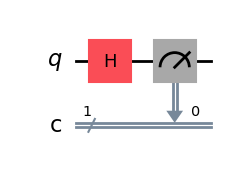

In [8]:
# Now reconstruct the circuit and add a measurement
# The second parameter of QuantumCircuit is the number of classical bits
circuit = QuantumCircuit(1,1) #creates one qubit and one classical bit.
circuit.h(0)

# The first list is the qubits to measure,
# the second list is the classical bits where the results go
circuit.measure([0],[0]) #take the result of qubit 0 and store it in classical bit 0.
circuit.draw("mpl")

In [9]:
# We will need to transpile the circuit into QASM instructions for the back end

# Use BasicSimulator
backend = BasicSimulator()

# Compile / transpile
qc_compiled = transpile(circuit, backend)

# Run the circuit on the simulator.
# We've set the number of repeats of the circuit
# to be 1024, which is the default.
# The qubits start in state |0>
job_sim = backend.run(qc_compiled, shots=1024)

# Grab the results from the job (this doesn't produce any output).
result_sim = job_sim.result()

In [10]:
# The simplest way to see the results of the simulation
counts = result_sim.get_counts(qc_compiled)
print(counts)

# The results are not exactly half 0 and half 1, but should be close.
# There will be different results each time the previous cell is run.

{'0': 491, '1': 533}


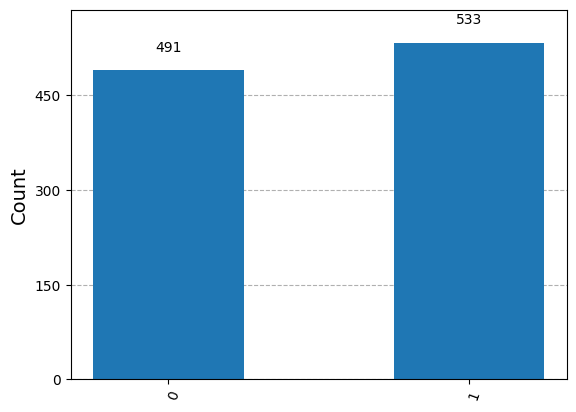

In [11]:
# We can also produce a graph

plot_histogram(counts)

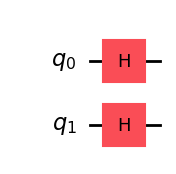

In [12]:
# Now let's move on to two qubits.
# Apply H to both qubits and see what we get.

circuit = QuantumCircuit(2)
circuit.h(0)
circuit.h(1)

circuit.draw("mpl")

In [13]:
state = Statevector.from_int(0, 4) # 4 is the number of basis states on 2 qubits
state = state.evolve(circuit)
state.draw("latex")

<IPython.core.display.Latex object>

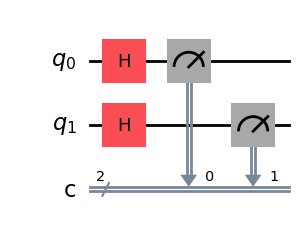

In [14]:
# Now measurement. This time we construct the measurement part
# of the circuit separately and then combine it with the first circuit.

# A new circuit with 2 qubits and 2 classical bits
meas = QuantumCircuit(2, 2) #creating a standalone circuit that only contains measurement instructions for two qubits.

# Map the quantum measurement to the classical bits
meas.measure(range(2), range(2)) #Measure qubit 0 into classical bit 0, and qubit 1 into classical bit 1.

# The Qiskit circuit object supports composition.
# Here the meas has to be first and front=True (putting it before)
# as compose must put a smaller circuit into a larger one.
qc = meas.compose(circuit, range(2), front=True) #tells Qiskit to take the existing circuit (which contained your Hadamard gates) and put it in front of the measurement instructions.

qc.draw("mpl")

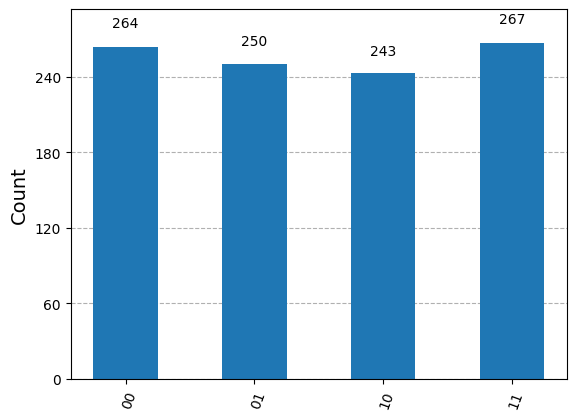

In [15]:
# Simulate again, using the same back end
qc_compiled = transpile(qc, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

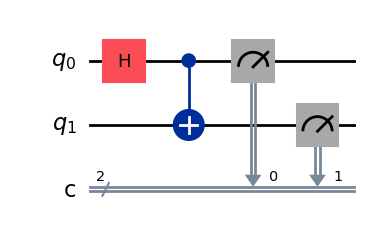

In [16]:
# Now for some entanglement.
# Construct a Bell state and measure both qubits to see that
# both measurements give the same result.

circuit = QuantumCircuit(2,2)
circuit.h(0)
circuit.cx(0,1) # cx means CNOT because it's a controlled version of x (negation)
circuit.measure(range(2),range(2))
circuit.draw("mpl")

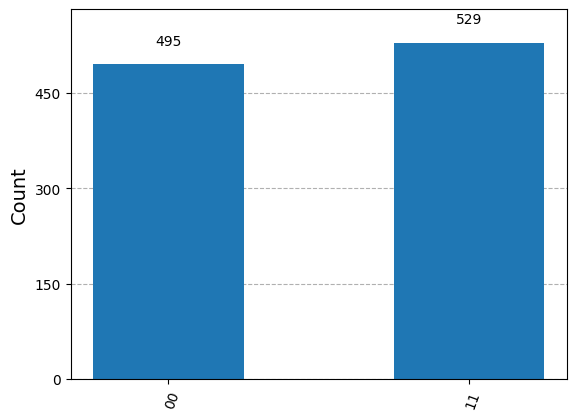

In [17]:
qc_compiled = transpile(circuit, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

In [18]:
# EXERCISE

# Make a copy here of the circuit that creates the Bell state 1/sqrt(2) ( |00> + |11> ).

# Modify it to create the other Bell states: 1/sqrt(2) ( |00> - |11> ), 1/sqrt(2) ( |01> + |10> ), 1/sqrt(2) ( |01> - |10> ).

# You will need to use X and Z gates. Check that your circuit is correct by displaying the state vector in each case.

# For each of the Bell states, repeat the simulation with measurements and check that the results are as expected.

### Bell State 2: $|\Phi^-\rangle = \frac{1}{\sqrt{2}}(|00\rangle - |11\rangle)$

State vector for |Φ⁻⟩:


<IPython.core.display.Latex object>

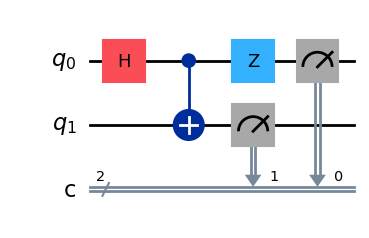

In [19]:
circuit_phi_minus = QuantumCircuit(2, 2)
circuit_phi_minus.h(0)
circuit_phi_minus.cx(0, 1)
circuit_phi_minus.z(0) # Apply Z gate to qubit 0

state_phi_minus = Statevector.from_int(0, 4).evolve(circuit_phi_minus)
print("State vector for |Φ⁻⟩:")
display(state_phi_minus.draw("latex"))

circuit_phi_minus.measure(range(2), range(2))
circuit_phi_minus.draw("mpl")

Measurement counts for |Φ⁻⟩:


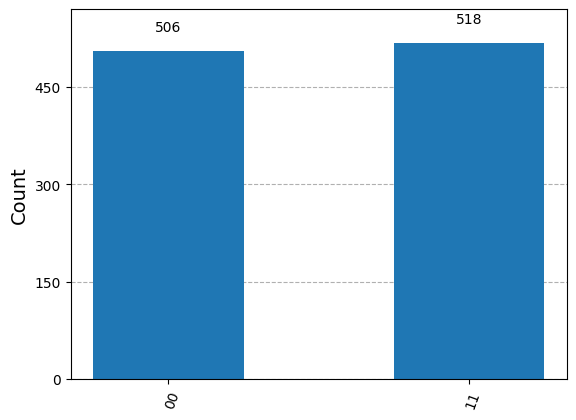

In [20]:
qc_compiled_phi_minus = transpile(circuit_phi_minus, backend)
job_sim_phi_minus = backend.run(qc_compiled_phi_minus, shots=1024)
result_sim_phi_minus = job_sim_phi_minus.result()
counts_phi_minus = result_sim_phi_minus.get_counts(qc_compiled_phi_minus)
print("Measurement counts for |Φ⁻⟩:")
plot_histogram(counts_phi_minus)

### Bell State 3: $|\Psi^+\rangle = \frac{1}{\sqrt{2}}(|01\rangle + |10\rangle)$

State vector for |Ψ⁺⟩:


<IPython.core.display.Latex object>

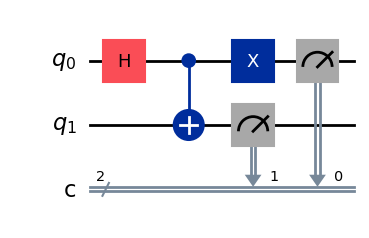

In [21]:
circuit_psi_plus = QuantumCircuit(2, 2)
circuit_psi_plus.h(0)
circuit_psi_plus.cx(0, 1)
circuit_psi_plus.x(0) # Apply X gate to qubit 0

state_psi_plus = Statevector.from_int(0, 4).evolve(circuit_psi_plus)
print("State vector for |Ψ⁺⟩:")
display(state_psi_plus.draw("latex"))

circuit_psi_plus.measure(range(2), range(2))
circuit_psi_plus.draw("mpl")

Measurement counts for |Ψ⁺⟩:


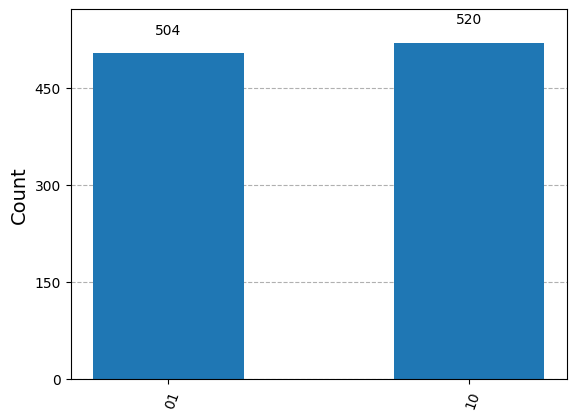

In [22]:
qc_compiled_psi_plus = transpile(circuit_psi_plus, backend)
job_sim_psi_plus = backend.run(qc_compiled_psi_plus, shots=1024)
result_sim_psi_plus = job_sim_psi_plus.result()
counts_psi_plus = result_sim_psi_plus.get_counts(qc_compiled_psi_plus)
print("Measurement counts for |Ψ⁺⟩:")
plot_histogram(counts_psi_plus)

### Bell State 4: $|\Psi^-\rangle = \frac{1}{\sqrt{2}}(|01\rangle - |10\rangle)$

State vector for |Ψ⁻⟩:


<IPython.core.display.Latex object>

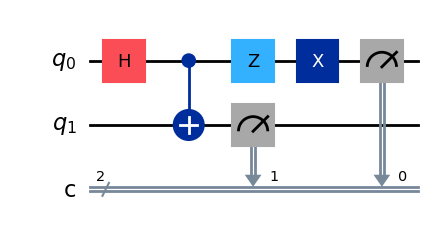

In [23]:
circuit_psi_minus = QuantumCircuit(2, 2)
circuit_psi_minus.h(0)
circuit_psi_minus.cx(0, 1)
circuit_psi_minus.z(0) # Start with |Φ⁻⟩
circuit_psi_minus.x(0) # Then apply X to transform to |Ψ⁻⟩

state_psi_minus = Statevector.from_int(0, 4).evolve(circuit_psi_minus)
print("State vector for |Ψ⁻⟩:")
display(state_psi_minus.draw("latex"))

circuit_psi_minus.measure(range(2), range(2))
circuit_psi_minus.draw("mpl")

Measurement counts for |Ψ⁻⟩:


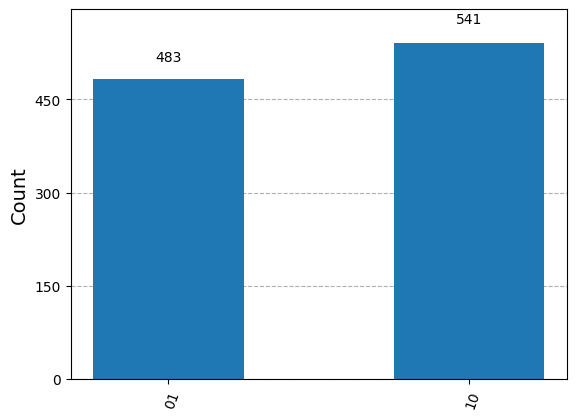

In [24]:
qc_compiled_psi_minus = transpile(circuit_psi_minus, backend)
job_sim_psi_minus = backend.run(qc_compiled_psi_minus, shots=1024)
result_sim_psi_minus = job_sim_psi_minus.result()
counts_psi_minus = result_sim_psi_minus.get_counts(qc_compiled_psi_minus)
print("Measurement counts for |Ψ⁻⟩:")
plot_histogram(counts_psi_minus)

In [25]:
# EXERCISE

# The GHZ state on any number of qubits has the form  1/sqrt(2) ( |00...0> + |11...1> )

# The Bell state 1/sqrt(2) ( |00> + |11> ) is the case for two qubits.

# Write code to construct a circuit that produces a GHZ state for any given number of qubits.

# Try simulating the circuit, with measurements. How many qubits can the simulator handle in a reasonable time?

### Constructing a GHZ State Circuit

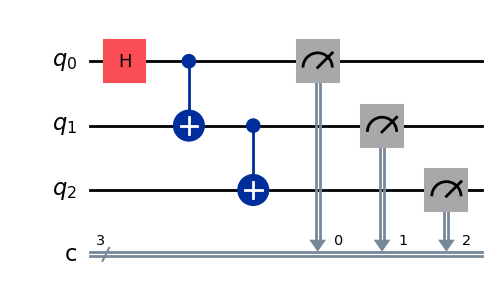

In [26]:
def create_ghz_state_circuit(num_qubits):
    """
    Creates a quantum circuit for a GHZ state with num_qubits.
    """
    # Create a quantum circuit with num_qubits and num_qubits classical bits for measurement
    circuit = QuantumCircuit(num_qubits, num_qubits)

    # Apply a Hadamard gate to the first qubit (q_0) to create a superposition
    circuit.h(0)

    # Apply CNOT gates between successive qubits to entangle them
    # The first qubit (q_0) acts as the control for all subsequent qubits
    for i in range(num_qubits - 1):
        circuit.cx(i, i + 1)

    # Add measurements for all qubits into their corresponding classical bits
    circuit.measure(range(num_qubits), range(num_qubits))

    return circuit

# Example: Create a 3-qubit GHZ state circuit
num_qubits_ghz = 3
ghz_circuit = create_ghz_state_circuit(num_qubits_ghz)

# Draw the circuit
ghz_circuit.draw("mpl")

### Simulating the GHZ State Circuit and Checking Measurements

Measurement counts for 3-qubit GHZ state:


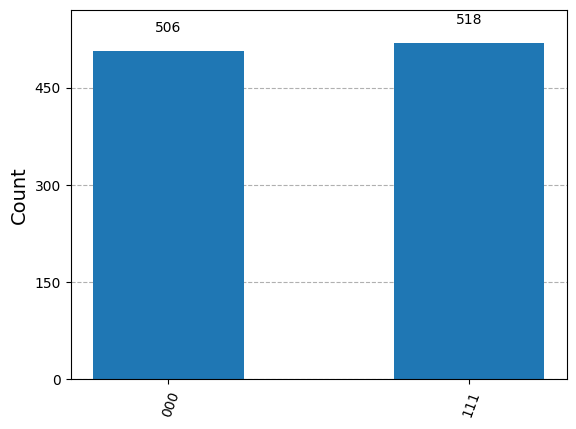

In [27]:
# Simulate the 3-qubit GHZ circuit
qc_compiled_ghz = transpile(ghz_circuit, backend)
job_sim_ghz = backend.run(qc_compiled_ghz, shots=1024)
result_sim_ghz = job_sim_ghz.result()
counts_ghz = result_sim_ghz.get_counts(qc_compiled_ghz)

print(f"Measurement counts for {num_qubits_ghz}-qubit GHZ state:")
plot_histogram(counts_ghz)

### Simulator Capabilities for GHZ States

The simulator's ability to handle GHZ states (or any quantum circuit) depends on several factors, primarily:

1.  **Number of Qubits:** The memory required to simulate a quantum state grows exponentially with the number of qubits ($2^n$, where $n$ is the number of qubits). For example, 10 qubits require $2^{10} = 1024$ complex amplitudes, while 30 qubits require $2^{30} \approx 10^9$ complex amplitudes. This rapidly becomes memory-intensive.

2.  **Circuit Depth and Gate Complexity:** While GHZ states are relatively simple in terms of gate count, more complex circuits with many gates can also increase simulation time.

3.  **Available Resources:** The amount of RAM and CPU available to the simulator significantly impacts performance. Local simulators like `BasicSimulator` in Qiskit will be limited by your machine's resources.

**Typical Limits:**

*   **Small-scale (up to ~20 qubits):** Most standard laptops/desktops can simulate circuits with up to 20-25 qubits in a reasonable time (seconds to minutes) using basic simulators, provided they have sufficient RAM (e.g., 16-32 GB).
*   **Medium-scale (~25-30 qubits):** This range often pushes the limits of local machines, requiring more powerful hardware or cloud-based quantum simulators.
*   **Large-scale (30+ qubits):** Simulating 30 or more qubits generally requires high-performance computing (HPC) clusters or specialized quantum simulation hardware. The memory requirement for 30 qubits is already in the gigabytes, and for 40 qubits, it's terabytes.

For this exercise, you'll likely find the `BasicSimulator` performing well for up to around 20-25 qubits before memory constraints or computation time become prohibitive. You can experiment by increasing `num_qubits_ghz` in the `create_ghz_state_circuit` function to observe these limitations firsthand.